# Download data from kaggle

In [1]:
!pip install -q kaggle

In [2]:
from google.colab import files
files.upload()

Saving kaggle (1).json to kaggle (1).json


{'kaggle (1).json': b'{"username":"armandatasets123456","key":"ef853bbed113049729583016e74b3cc5"}'}

In [3]:
# Dataset download
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:17<00:00, 144MB/s]



In [4]:
# unzip the file
!unzip -q chest-xray-pneumonia.zip

In [5]:
# import needed libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## File Distribution Analysis

In [6]:
import os
for folder in os.listdir("/content/chest_xray"):
  print(f"\n==={folder}====\n")
  print(os.listdir(f"/content/chest_xray/{folder}"))



===chest_xray====

['val', 'train', '.DS_Store', 'test']

===val====

['NORMAL', 'PNEUMONIA']

===train====

['NORMAL', 'PNEUMONIA']

===__MACOSX====

['._chest_xray', 'chest_xray']

===test====

['NORMAL', 'PNEUMONIA']



=== train === 

Normal : - 1342
Pneumonia : - 3876


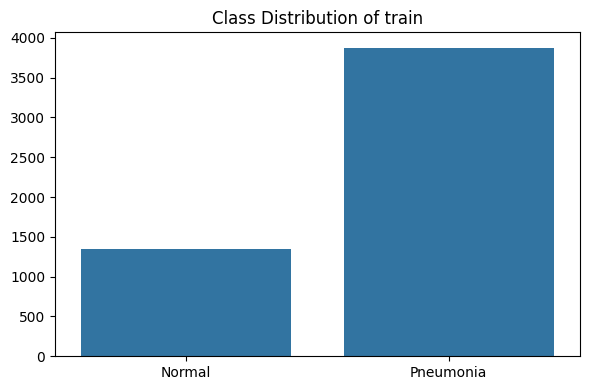


=== test === 

Normal : - 234
Pneumonia : - 390


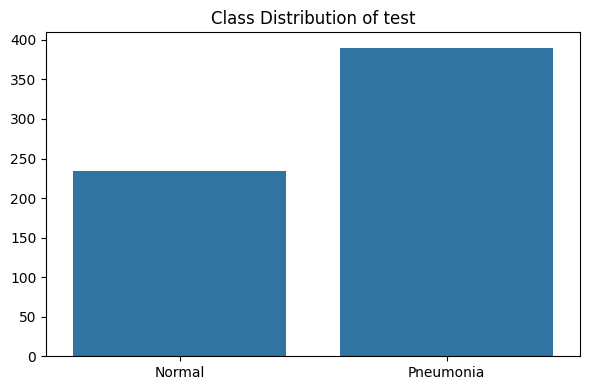


=== val === 

Normal : - 9
Pneumonia : - 9


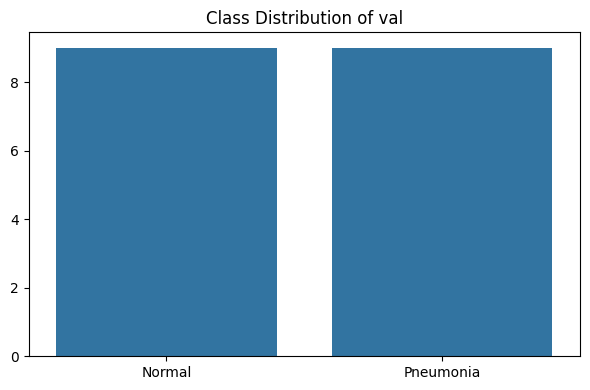

In [7]:
# train_path distribution
train_path="/content/chest_xray/chest_xray"

for folder in ["train","test","val"]:
  print(f"\n=== {folder} === \n")

  normal=len(os.listdir(f"{train_path}/{folder}/NORMAL"))
  pneumonia=len(os.listdir(f"{train_path}/{folder}/PNEUMONIA"))

  print(f"Normal : - {normal}")
  print(f"Pneumonia : - {pneumonia}")

  # visualization
  plt.figure(figsize=(6,4))
  sns.barplot(x=["Normal","Pneumonia"],y=[normal,pneumonia])
  plt.title(f"Class Distribution of {folder}")

  plt.tight_layout()
  plt.show()

#### As we can see trian data is extremely imbalanced . and there is less data in val_data so we can't use it for validation , we split data from train data for validation

## Data Preprocessing

In [8]:
# load the file
import tensorflow as tf
from tensorflow import keras

train_ds=keras.utils.image_dataset_from_directory(
    "/content/chest_xray/chest_xray/train",
    batch_size=32,
    image_size=(224,224),
    shuffle=True,
    subset="training",
    validation_split=0.2,
    seed=42
)

# val_data
val_ds=keras.utils.image_dataset_from_directory(
    "/content/chest_xray/chest_xray/train",
    batch_size=32,
    image_size=(224,224),
    validation_split=0.2,
    subset="validation",
    seed=42
)

# test_data
test_ds=keras.utils.image_dataset_from_directory(
    "/content/chest_xray/chest_xray/test",
    batch_size=32,
    image_size=(224,224),
    shuffle=False
    )

Found 5216 files belonging to 2 classes.
Using 4173 files for training.
Found 5216 files belonging to 2 classes.
Using 1043 files for validation.
Found 624 files belonging to 2 classes.


# Shape of the File

In [9]:
# train_ds
for name,folder in [("train_ds",train_ds),("test_ds",test_ds),("val_ds",val_ds)]:
  for image,labels in folder.take(1):
    print(f"\n==={name}===\n")
    print(f"image shape :{image.shape}")
    print(f"labels shape : {labels.shape}")


===train_ds===

image shape :(32, 224, 224, 3)
labels shape : (32,)

===test_ds===

image shape :(32, 224, 224, 3)
labels shape : (32,)

===val_ds===

image shape :(32, 224, 224, 3)
labels shape : (32,)


# show somo training image

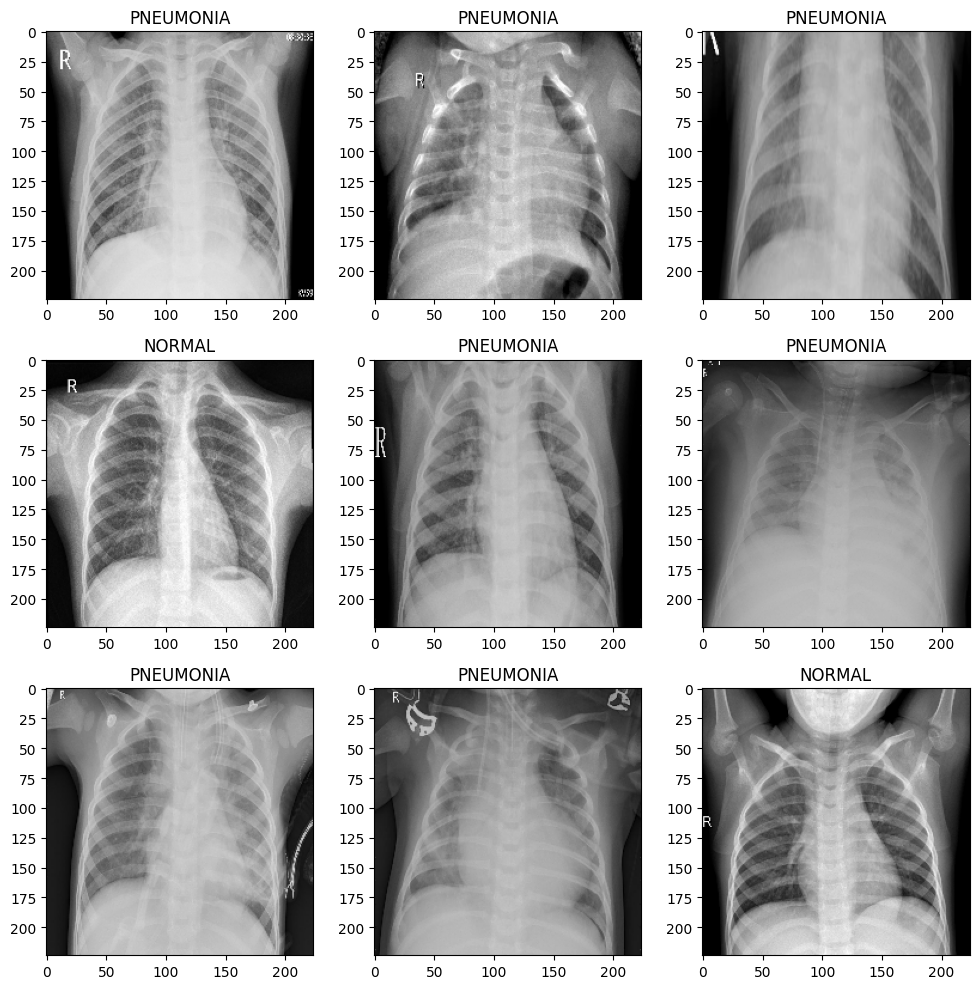

In [10]:
class_name=train_ds.class_names
for image in train_ds.take(1):

  plt.figure(figsize=(10,10))
  for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(image[0][i].numpy().astype('uint8'))
    plt.title(class_name[image[1][i]])

  plt.tight_layout()
  plt.show()


## Handling Imbalanced

In [11]:
normal=len(os.listdir("/content/chest_xray/chest_xray/train/NORMAL"))
pneumonia=len(os.listdir("/content/chest_xray/chest_xray/train/PNEUMONIA"))

total=normal+pneumonia

normal_weight=(total)/(2*normal)
pneumonia_weight=(total)/(2*pneumonia)

# adjustin in class_weight dict
class_weight={
    0:normal_weight,
    1:pneumonia_weight
}
print(class_weight)

{0: 1.9441132637853948, 1: 0.6731166150670794}


## Model Building

In [12]:
from keras.layers import Conv2D,MaxPooling2D,Flatten,Dense,Dropout,BatchNormalization,GlobalAveragePooling2D
from keras.models import Sequential
from keras.layers import RandomFlip,RandomRotation,RandomZoom,RandomContrast

In [13]:
# apply data augmentation
data_augmentation=Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.25),
    RandomZoom(0.25),
    RandomContrast(0.25)
])

In [14]:
# use transfer Learning Model
from keras.applications import EfficientNetB2

base_model=EfficientNetB2(
    include_top=False,
    weights="imagenet",
    input_shape=(224,224,3)
)
base_model.trainable = True


31790344/31790344 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [15]:
# building Cnn model

model=Sequential()

# apply data augmentation
model.add(data_augmentation)

# apply transfer learning
model.add(base_model)

# Make base model trainable
base_model.trainable = True

# Freeze first 40 layers
fine_tune_at = 40

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# Keep BatchNormalization layers frozen
for layer in base_model.layers:
    if isinstance(layer, BatchNormalization):
        layer.trainable = False

# apply GlobalAveragePooling
model.add(GlobalAveragePooling2D())

# apply feed_forward network
model.add(Dense(128,activation="relu"))
model.add(BatchNormalization())
model.add(Dropout(0.2))

model.add(Dense(64,activation="relu"))
model.add(BatchNormalization())
model.add(Dropout(0.2))

# output
model.add(Dense(1,activation="sigmoid"))

In [16]:
# summary of model
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb2 (Functional)     │ (None, 7, 7, 1408)     │     7,768,569 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,768,569 (29.63 MB)

 Trainable params: 7,627,874 (29.10 MB)

 Non-trainable params: 140,695 (549.59 KB)

In [17]:
# compile the notes
import tensorflow as tf
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.Precision(name="precision")
    ]
)

In [18]:
# fit the model
history=model.fit(
    train_ds,
    epochs=10,
    validation_data=val_ds,
    class_weight=class_weight
)

Epoch 1/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 92s 391ms/step - loss: 0.6468 - precision: 0.8758 - recall: 0.5790 - val_loss: 0.5113 - val_precision: 0.9899 - val_recall: 0.7443
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 49s 370ms/step - loss: 0.4189 - precision: 0.9669 - recall: 0.7020 - val_loss: 0.4743 - val_precision: 0.9919 - val_recall: 0.7695
Epoch 3/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 47s 355ms/step - loss: 0.3393 - precision: 0.9823 - recall: 0.7757 - val_loss: 0.3604 - val_precision: 0.9928 - val_recall: 0.8652
Epoch 4/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 84s 372ms/step - loss: 0.2917 - precision: 0.9834 - recall: 0.8277 - val_loss: 0.4116 - val_precision: 0.9927 - val_recall: 0.8602
Epoch 5/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 48s 365ms/step - loss: 0.2678 - precision: 0.9792 - recall: 0.8536 - val_loss: 0.3166 - val_precision: 0.9916 - val_recall: 0.8929
Epoch 6/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 82s 363ms/step - loss: 0.2289 - precision: 0.9851 - recall: 0.8770 - val_loss: 0.3333 - val_precision: 0.

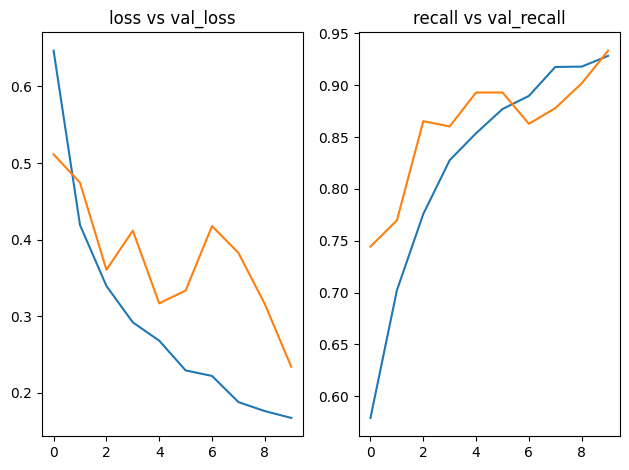

In [19]:
 # plot the history of model
plt.subplot(121)
plt.plot(history.history["loss"])
plt.plot(history.history['val_loss'])
plt.title("loss vs val_loss")

plt.subplot(122)
plt.plot(history.history["recall"])
plt.plot(history.history['val_recall'])
plt.title("recall vs val_recall")

plt.tight_layout()
plt.show()

In [20]:
# check model performance on unseen data
test_results = model.evaluate(test_ds, return_dict=True)

print(test_results)

20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 174ms/step - loss: 0.2387 - precision: 0.9026 - recall: 0.9744
{'loss': 0.2386886179447174, 'precision': 0.9026128053665161, 'recall': 0.9743589758872986}


# Model Evaluation

In [24]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, f1_score, roc_auc_score

y_true = []
y_pred_prob = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred_prob.extend(preds.ravel())

y_true = np.array(y_true)
y_pred_prob = np.array(y_pred_prob)

y_pred = (y_pred_prob >= 0.5).astype(int)

print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))

print("\nClassification Report:")
print(classification_report(
    y_true,
    y_pred,
    target_names=["Normal", "Pneumonia"]
))

print("F1 Score:", f1_score(y_true, y_pred))
print("ROC-AUC:", roc_auc_score(y_true, y_pred_prob))

Confusion Matrix:
[[193  41]
 [ 10 380]]

Classification Report:
              precision    recall  f1-score   support

      Normal       0.95      0.82      0.88       234
   Pneumonia       0.90      0.97      0.94       390

    accuracy                           0.92       624
   macro avg       0.93      0.90      0.91       624
weighted avg       0.92      0.92      0.92       624

F1 Score: 0.93711467324291
ROC-AUC: 0.9652531229454306


In [ ]:
# save the model
model.save("pneumonia_model.keras")

In [ ]:
model=keras.models.load_model("models/pneumonia_model.keras")